# Tahap 4: Uji Lanjutan Metode Atlas Ekonomi Kreatif Jakarta
### JEF 2026 · Topik 4a · Menutup celah metodologis dari penelusuran pustaka

Catatan kerja ini melanjutkan Tahap 3. Kita menguji lima pilihan metode yang paling mungkin dipertanyakan juri, lalu mencetak interpretasi langsung dari hasil run. Status kuartil jurnal tidak dibahas di sini karena tidak memerlukan pengolahan data.

| Uji | Celah | Cara menutupnya |
|---|---|---|
| A | Sembilan lokasi Simpul Kreatif dipilih dengan *greedy algorithm* | Solusi eksak *integer programming* (HiGHS melalui `scipy.optimize.milp`) untuk p = 1–15, tiga radius, dan dua himpunan kandidat |
| B | 2SFCA memakai *catchment* biner tanpa peluruhan jarak (*distance decay*) | E2SFCA (bobot zona 1,00; 0,68; 0,22; Luo dan Qi, 2009) dan Gaussian 2SFCA (Dai, 2010) pada 48 skenario yang sama |
| C | Kelayakan transit diukur dengan *buffer* garis lurus | Jarak jaringan jalan kaki OpenStreetMap ke halte dan stasiun |
| D | Akses diukur dengan jarak garis lurus | 2SFCA berbasis jarak jaringan untuk skenario utama, termasuk MCLP greedy dan eksak |
| E | Keragaman hanya diukur dengan entropi Shannon | Bilangan Hill orde 0, 1, dan 2 (Hill, 1973) yang dirarefaksi |

**Cara menjalankan.** Notebook dijalankan dari root repositori, di folder yang sama dengan notebook Tahap 3 (`cp notebooks/*.ipynb .`). Bila objek Tahap 3 belum ada di memori, SEL 1 menjalankan ulang notebook Tahap 3 dari snapshot tersimpan (butuh `worldpop_jakarta.tif` dan raster WorldPop nasional di `data/raw/`, sama seperti Tahap 3), lalu mencocokkan angka utamanya dengan `hasil_tahap3.json` run sebelumnya. Paket tambahan tidak diperlukan: solusi eksak memakai `scipy` ≥ 1.9 dan jaringan jalan memakai `osmnx`.

**Jaringan jalan kaki.** SEL 4 mengunduh jaringan `walk` OSM untuk 42 kecamatan dan *buffer* 3,5 km sekali saja, lalu menyimpannya di `data/processed/jaringan_jalan_kaki/`. Bila Overpass tidak dapat dihubungi, SEL 4 memakai `data/raw/jalan_jakarta.osm` (lihat keterangan SEL 4). Uji C dan D dilewati bila keduanya tidak tersedia.

Urutan jalan: **Kernel → Restart → Run All**. Keluaran: tabel di `outputs/tahap4/tables/`, gambar di `outputs/tahap4/figures/`, dan ringkasan di `data/processed/hasil_tahap4.json`.

## SEL 1: Memuat objek Tahap 3, parameter, dan fungsi bantu

Semua uji memakai objek yang sama dengan Tahap 3: piksel penduduk terkalibrasi, titik pasokan gabungan OSM dan Overture, kandidat lokasi, definisi akses rendah, dan fungsi agregasi kecamatan. Dengan begitu, perbedaan hasil hanya berasal dari metode yang diuji. Sebelum menjalankan ulang Tahap 3, sel ini membaca `hasil_tahap3.json` run sebelumnya untuk memeriksa bahwa angka utamanya tidak berubah.

In [1]:
# ============ SEL 1: MUAT OBJEK TAHAP 3, PARAMETER, FUNGSI BANTU ============
import json, math, time, textwrap, warnings
from pathlib import Path
from datetime import datetime, timezone
warnings.filterwarnings("ignore")

# Isi dengan nama berkas notebook Tahap 3 bila ingin memilih sendiri, misalnya "03_revisi_analisis_ekraf_jakarta_v6.ipynb".
# Bila None, notebook "03_*.ipynb" yang paling baru diubah di folder kerja atau di subfolder notebooks/ dipakai.
NB_TAHAP3_MANUAL = None

def _cari_tahap3():
    if NB_TAHAP3_MANUAL:
        p = Path.cwd() / NB_TAHAP3_MANUAL
        return p if p.exists() else None
    kandidat = [p for pola in ("03_*.ipynb", "notebooks/03_*.ipynb") for p in Path.cwd().glob(pola)
                if "checkpoint" not in p.name.lower() and ".ipynb_checkpoints" not in p.parts]
    if not kandidat:
        return None
    kandidat = sorted(kandidat, key=lambda p: p.stat().st_mtime, reverse=True)
    print("Kandidat notebook Tahap 3 (terbaru di atas):")
    for p in kandidat:
        print(f"  {datetime.fromtimestamp(p.stat().st_mtime):%d-%m-%Y %H.%M}  {p.relative_to(Path.cwd())}")
    return kandidat[0]

NB_TAHAP3 = _cari_tahap3()
HASIL3_JSON = Path.cwd() / "data" / "processed" / "hasil_tahap3.json"
_PERLU = ["PIX", "P_XY", "TREE_PIX", "PASOKAN", "_semua_xy", "SUP_UTAMA", "SUP_STABIL", "VARIAN_POP", "POP",
          "POP_UTAMA_NAMA", "KEBUTUHAN", "KEB_UTAMA", "KOL_KEB", "CALON", "CALON_UTAMA", "cakupan_calon", "mclp",
          "akses_rendah", "agregat_kec", "AKSES", "AK", "LOKASI", "FREK_TOP", "_bobot0", "_keb0", "TIPIS",
          "KEC_I", "KEC_NAMA", "poi", "ovt", "KLASTER", "ENT", "RESULTS", "A_REF0", "AMBANG_RENDAH"]

RUJUKAN3 = None
if HASIL3_JSON.exists():
    _h3 = json.loads(HASIL3_JSON.read_text(encoding="utf-8"))
    RUJUKAN3 = {"run_utc": _h3.get("run_utc"), "akses_rendah": _h3["akses"]["akses_rendah"],
                "cakupan_mclp": _h3["akses"]["cakupan_mclp"], "prioritas_stabil": _h3["akses"]["prioritas_stabil"]}

DIJALANKAN_ULANG = False
if not all(k in globals() for k in _PERLU):
    assert NB_TAHAP3 is not None, (f"Notebook Tahap 3 (03_*.ipynb) tidak ditemukan di {Path.cwd()} maupun di subfolder "
                                   "notebooks/. Isi NB_TAHAP3_MANUAL dengan nama berkasnya.")
    _rel = NB_TAHAP3.relative_to(Path.cwd())
    from IPython.utils.capture import capture_output
    print(f"\nObjek Tahap 3 belum ada di memori; menjalankan {_rel} dari snapshot tersimpan ...")
    _t0, _cap = time.time(), None
    try:
        with capture_output() as _cap:
            get_ipython().run_line_magic("run", f'"{_rel}"')      # tanda kutip: aman untuk nama dengan spasi atau kurung
    except Exception:
        if _cap is not None:
            print(_cap.stdout[-3000:])
        raise
    DIJALANKAN_ULANG = True
    print(f"Tahap 3 selesai dalam {time.time() - _t0:,.0f} detik; keluaran Tahap 3 ikut ditulis ulang.")
_hilang = [k for k in _PERLU if k not in globals()]
assert not _hilang, (f"Objek Tahap 3 belum lengkap: {_hilang}. Kemungkinan notebook yang dijalankan "
                     f"({NB_TAHAP3.name if NB_TAHAP3 else '-'}) bukan versi terakhir; isi NB_TAHAP3_MANUAL.")

import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import scipy
from scipy import sparse
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse.csgraph import dijkstra, connected_components
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from pyproj import Transformer

# ---------- parameter ----------
OUT4 = BASE / "outputs" / "tahap4"
FIG4, TAB4 = OUT4 / "figures", OUT4 / "tables"
for _p in (FIG4, TAB4):
    _p.mkdir(parents=True, exist_ok=True)
P_MAKS = 15                          # jumlah simpul terbesar pada kurva greedy vs eksak
MILP_BATAS_DETIK = 600               # batas waktu solver per model
BOBOT_E2SFCA = (1.00, 0.68, 0.22)    # bobot tiga zona (Luo dan Qi, 2009)
HITUNG_JARINGAN = True               # False = uji C dan D dilewati
JARINGAN_DIR = PROC / "jaringan_jalan_kaki"
PENYANGGA_JARINGAN_M = CINCIN_M + 500
BATAS_HALTE_M, BATAS_STASIUN_M = 400, 800
MEMORI_DIJKSTRA = 2e8                # byte per blok matriks jarak Dijkstra
RNG4 = np.random.default_rng(SEED)

# ---------- fungsi bantu ----------
CATATAN4 = []
def mulai4(bagian):
    CATATAN4[:] = [c for c in CATATAN4 if c[0] != bagian]

def catat4(bagian, teks):
    CATATAN4.append((bagian, teks))
    print(teks)

def simpan4(fig, nama):
    fig.savefig(FIG4 / nama, bbox_inches="tight", facecolor="white")
    print("  gambar tersimpan:", nama)

def arah_pp(x_pp, d=1):
    # x_pp sudah dalam poin persen
    return ("turun " if x_pp < 0 else "naik ") + fnum(abs(x_pp), d) + " poin persen"

def status_frek(f):
    return "Prioritas utama" if f >= 0.8 else ("Prioritas lanjutan" if f >= 0.5 else "-")

pop0 = PIX[POP].to_numpy()
TOTAL_KEB0 = float(_bobot0.sum())
RESULTS4 = {"run_utc": datetime.now(timezone.utc).isoformat(), "run_utc_tahap3": RESULTS.get("run_utc"),
            "notebook_tahap3": NB_TAHAP3.name if NB_TAHAP3 else None,
            "param": {"p_maks": P_MAKS, "bobot_e2sfca": BOBOT_E2SFCA, "penyangga_jaringan_m": PENYANGGA_JARINGAN_M,
                      "batas_halte_m": BATAS_HALTE_M, "batas_stasiun_m": BATAS_STASIUN_M, "seed": SEED}}

print(f"\nscipy {scipy.__version__} | osmnx {'ada' if HAS_OX else 'TIDAK ADA'}")
print(f"Skenario utama Tahap 3: d0 = {fnum(D0_UTAMA)} m | pasokan {SUP_UTAMA} | penduduk {POP_UTAMA_NAMA} | kebutuhan {KEB_UTAMA}")
print(f"Penduduk akses rendah: {fnum(RESULTS['akses']['akses_rendah'])} jiwa | di sel data memadai: {fnum(TOTAL_KEB0)} jiwa | "
      f"cakupan sembilan simpul: {fpct(RESULTS['akses']['cakupan_mclp'])}")

print("\nInterpretasi:")
mulai4("dasar")
if RUJUKAN3 is None:
    catat4("dasar", "Berkas hasil_tahap3.json run sebelumnya tidak ditemukan, sehingga angka Tahap 3 di memori tidak dapat "
           "dicocokkan dengan run tersimpan.")
else:
    _beda = []
    if abs(RESULTS["akses"]["akses_rendah"] - RUJUKAN3["akses_rendah"]) >= 1:
        _beda.append(f"penduduk akses rendah {fnum(RUJUKAN3['akses_rendah'])} → {fnum(RESULTS['akses']['akses_rendah'])}")
    if abs(RESULTS["akses"]["cakupan_mclp"] - RUJUKAN3["cakupan_mclp"]) >= 1e-6:
        _beda.append(f"cakupan simpul {fpct(RUJUKAN3['cakupan_mclp'])} → {fpct(RESULTS['akses']['cakupan_mclp'])}")
    if list(RESULTS["akses"]["prioritas_stabil"]) != list(RUJUKAN3["prioritas_stabil"]):
        _beda.append("daftar prioritas utama berubah")
    if _beda:
        catat4("dasar", f"Angka Tahap 3 di memori berbeda dari run tersimpan ({RUJUKAN3['run_utc']}): " + "; ".join(_beda)
               + ". Uji di notebook ini dibandingkan dengan angka Tahap 3 yang sedang ada di memori.")
    else:
        catat4("dasar", f"Angka utama Tahap 3 di memori sama dengan run tersimpan ({RUJUKAN3['run_utc']}): "
               f"{fnum(RESULTS['akses']['akses_rendah'])} penduduk akses rendah, cakupan sembilan simpul "
               f"{fpct(RESULTS['akses']['cakupan_mclp'])}, dan prioritas utama "
               f"{', '.join(RESULTS['akses']['prioritas_stabil'])}.")
RESULTS4["dasar"] = {"dijalankan_ulang": DIJALANKAN_ULANG, "notebook_tahap3": NB_TAHAP3.name if NB_TAHAP3 else None,
                     "rujukan_tersimpan": RUJUKAN3}

Kandidat notebook Tahap 3 (terbaru di atas):
  28-09-2026 02.37  03_revisi_analisis_ekraf_jakarta_v6.ipynb
  27-09-2026 22.21  03_revisi_analisis_ekraf_jakarta(v5).ipynb
  25-09-2026 13.31  03_revisi_analisis_ekraf_jakarta(v4).ipynb
  25-09-2026 07.21  03_revisi_analisis_ekraf_jakarta(v3).ipynb

Objek Tahap 3 belum ada di memori; menjalankan 03_revisi_analisis_ekraf_jakarta_v6.ipynb dari snapshot tersimpan ...
Tahap 3 selesai dalam 192 detik; keluaran Tahap 3 ikut ditulis ulang.

scipy 1.14.1 | osmnx ada
Skenario utama Tahap 3: d0 = 1.500 m | pasokan gabungan ruang kreatif publik | penduduk WorldPop dikalibrasi data resmi | kebutuhan data memadai
Penduduk akses rendah: 1.766.634 jiwa | di sel data memadai: 1.740.478 jiwa | cakupan sembilan simpul: 48,8%

Interpretasi:
Angka utama Tahap 3 di memori sama dengan run tersimpan (2026-09-27T19:09:59.445545+00:00): 1.766.634 penduduk akses rendah, cakupan sembilan simpul 48,8%, dan prioritas utama Cakung, Kalideres, Cengkareng, Cilincing, Cip

## SEL 2: Uji A, MCLP eksak dibandingkan dengan greedy

Tahap 3 memilih sembilan lokasi dengan *greedy algorithm*: di setiap langkah dipilih kandidat yang menambah penduduk akses rendah terjangkau paling banyak. Untuk fungsi cakupan, greedy dijamin mencapai sedikitnya $1 - (1 - 1/p)^p$ dari nilai optimum (Nemhauser dkk., 1978), atau 65,4 persen untuk p = 9. Jaminan ini adalah batas terburuk, sehingga selisih yang sebenarnya perlu diukur.

MCLP (Church dan ReVelle, 1974) kita selesaikan secara eksak:

$$\max \sum_s w_s z_s \quad \text{dengan} \quad z_s \le \sum_{j \in N_s} y_j,\quad \sum_j y_j = p,\quad y_j \in \{0, 1\},\quad 0 \le z_s \le 1$$

Piksel dengan himpunan kandidat penjangkau yang sama digabung menjadi satu baris $s$ dengan bobot $w_s$ sebesar jumlah penduduk akses rendahnya. Penggabungan ini memperkecil model tanpa mengubah solusi. Bobot, kandidat, dan radius sama persis dengan Tahap 3. Uji dijalankan untuk p = 1–15 pada skenario utama, lalu untuk p = 9 pada tiga radius dan dua himpunan kandidat (fasilitas publik OSM dan titik tengah sel H3).

Model skenario utama: 316 kandidat, 616 kelompok piksel (dari 13.142 piksel berbobot)

Greedy vs eksak, skenario utama:
 p greedy eksak  selisih_pp jaminan  lokasi_sama  status_solver  detik
 1   8,3%  8,3%       0.000  100,0%            1              0   0.52
 2  15,0% 15,0%       0.000   75,0%            2              0   0.02
 3  21,2% 21,2%       0.000   70,4%            3              0   0.02
 4  26,8% 26,8%       0.000   68,4%            4              0   0.02
 5  32,2% 32,2%       0.000   67,2%            5              0   0.01
 6  36,8% 36,9%       0.091   66,5%            4              0   0.01
 7  41,4% 41,5%       0.091   66,0%            5              0   0.02
 8  45,5% 45,6%       0.091   65,6%            6              0   0.02
 9  48,8% 49,4%       0.598   65,4%            6              0   0.02
10  51,6% 52,2%       0.598   65,1%            7              0   0.02
11  54,3% 54,9%       0.599   65,0%            7              0   0.02
12  57,0% 57,6%       0.599 

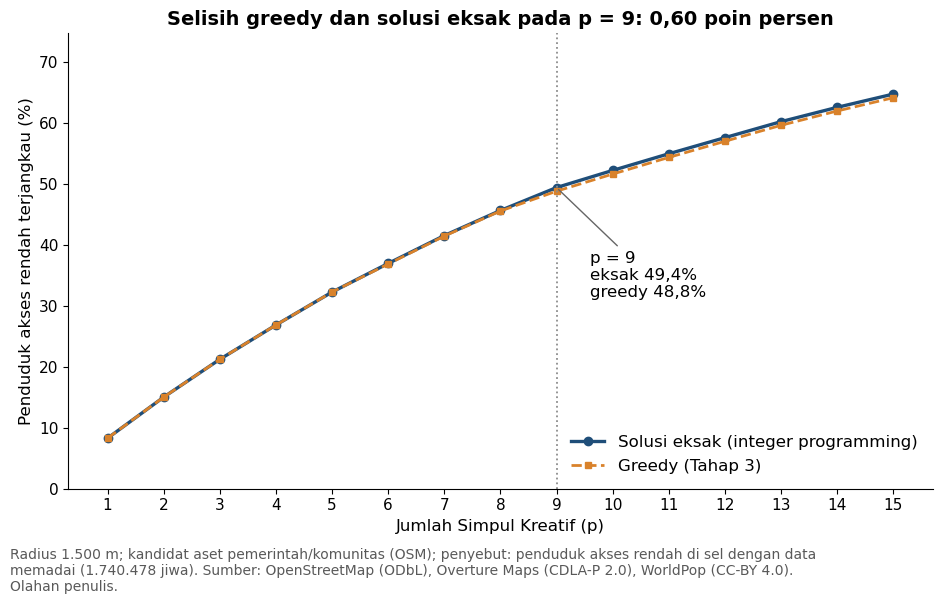


Interpretasi:
Pada skenario utama, sembilan simpul hasil greedy menjangkau 48,8% penduduk akses rendah, sedangkan solusi eksak menjangkau 49,4%; greedy tertinggal 0,60 poin persen, atau mencapai 98,8% dari optimum. Jaminan teoretis greedy untuk p = 9 adalah 65,4% dari optimum, dan rasio yang teramati berada di atas batas itu. Sebanyak 6 dari 9 lokasi sama pada kedua solusi. Solver menyatakan solusi eksak optimal.
Untuk p = 1 sampai 15, selisih terbesar antara solusi eksak dan greedy adalah 0,60 poin persen pada p = 14; rasio greedy terhadap optimum terendah 98,8%.
Pada p = 9 untuk setiap radius dan himpunan kandidat, selisih eksak dan greedy: radius 1,0 km, titik tengah sel H3: 0,00 poin persen; radius 1,0 km, aset pemerintah/komunitas (OSM): 0,03 poin persen; radius 1,5 km, titik tengah sel H3: 2,00 poin persen; radius 1,5 km, aset pemerintah/komunitas (OSM): 0,60 poin persen; radius 2,5 km, titik tengah sel H3: 2,11 poin persen; radius 2,5 km, aset pemerintah/komunitas (OSM): 1,54 p

In [2]:
# ============ SEL 2: UJI A, MCLP EKSAK VS GREEDY ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
mulai4("mclp")

def matriks_cakupan(lists, bobot):
    # baris = kelompok piksel berbobot positif dengan himpunan kandidat penjangkau yang sama; kolom = kandidat
    bobot = np.asarray(bobot, float)
    lens = np.array([len(l) for l in lists], dtype=np.int64)
    if lens.sum() == 0:
        return sparse.csr_matrix((0, len(lists))), np.zeros(0)
    rows = np.concatenate([np.asarray(l, dtype=np.int64) for l in lists])
    cols = np.repeat(np.arange(len(lists)), lens)
    ok = bobot[rows] > 0
    M = sparse.csr_matrix((np.ones(int(ok.sum())), (rows[ok], cols[ok])), shape=(len(bobot), len(lists)))
    M.sum_duplicates()
    M.sort_indices()
    grup, W, baris = {}, [], []
    for i in np.nonzero(np.diff(M.indptr) > 0)[0]:
        c = M.indices[M.indptr[i]:M.indptr[i + 1]]
        g = grup.get(c.tobytes())
        if g is None:
            grup[c.tobytes()] = len(W)
            W.append(bobot[i])
            baris.append(c.copy())
        else:
            W[g] += bobot[i]
    lb = np.array([len(b) for b in baris], dtype=np.int64)
    C = sparse.csr_matrix((np.ones(int(lb.sum())), (np.repeat(np.arange(len(baris)), lb), np.concatenate(baris))),
                          shape=(len(baris), len(lists)))
    return C, np.asarray(W, float)

def mclp_eksak(C, W, p, batas_detik=MILP_BATAS_DETIK):
    n_s, n_c = C.shape
    skala = max(W.sum(), 1.0)
    A1 = sparse.hstack([-C, sparse.identity(n_s, format="csr")], format="csr")      # z_s - sum y_j <= 0
    A2 = sparse.csr_matrix(np.r_[np.ones(n_c), np.zeros(n_s)][None, :])              # sum y_j = p
    res = milp(c=np.r_[np.zeros(n_c), -W / skala],
               constraints=[LinearConstraint(A1, -np.inf, 0.0), LinearConstraint(A2, p, p)],
               integrality=np.r_[np.ones(n_c), np.zeros(n_s)], bounds=Bounds(0, 1),
               options={"time_limit": batas_detik, "disp": False})
    if res.x is None:
        return np.array([], dtype=int), np.nan, res
    pilih = np.nonzero(res.x[:n_c] > 0.5)[0]
    terjangkau = float(W[np.asarray(C[:, pilih].sum(axis=1)).ravel() > 0].sum())
    return pilih, terjangkau, res

def bobot_skenario(d0, sup=None, pnama=None):
    sup, pnama = sup or SUP_UTAMA, pnama or POP_UTAMA_NAMA
    pop = PIX[VARIAN_POP[pnama]].to_numpy()
    A, n_in, _ = AKSES[(d0, sup, pnama)]
    rendah, _ = akses_rendah(A, n_in, pop)
    return pop * rendah * ((~TIPIS) if KEB_UTAMA == "data memadai" else 1.0)

assert np.allclose(bobot_skenario(D0_UTAMA), _bobot0), "Bobot skenario utama berbeda dari Tahap 3."

# ---- (a) kurva p = 1..P_MAKS pada skenario utama ----
_lc0 = cakupan_calon(CALON_UTAMA, D0_UTAMA)
_C0, _W0 = matriks_cakupan(_lc0, _bobot0)
PILIH_GREEDY, _tam_g = mclp(_lc0, _bobot0, k=P_MAKS)
_cum_g = np.cumsum(_tam_g)
assert np.allclose(_cum_g[:len(LOKASI)], LOKASI["kumulatif"].to_numpy()), "Urutan greedy berbeda dari LOKASI Tahap 3."
print(f"Model skenario utama: {fnum(_C0.shape[1])} kandidat, {fnum(_C0.shape[0])} kelompok piksel "
      f"(dari {fnum(int((_bobot0 > 0).sum()))} piksel berbobot)")
PILIH_EKSAK, _baris = {}, []
for p in range(1, P_MAKS + 1):
    _t = time.time()
    pil, nilai, res = mclp_eksak(_C0, _W0, p)
    PILIH_EKSAK[p] = pil
    g = float(_cum_g[min(p, len(_cum_g)) - 1])
    _baris.append({"p": p, "greedy_jiwa": g, "eksak_jiwa": nilai, "greedy_pct": g / TOTAL_KEB0,
                   "eksak_pct": nilai / TOTAL_KEB0, "selisih_pp": 100 * (nilai - g) / TOTAL_KEB0,
                   "rasio_greedy_eksak": g / nilai if nilai > 0 else np.nan, "jaminan_teoretis": 1 - (1 - 1 / p) ** p,
                   "lokasi_sama": len(set(PILIH_GREEDY[:p]) & set(pil)), "status_solver": int(res.status),
                   "detik": round(time.time() - _t, 2)})
TAB_MCLP_P = pd.DataFrame(_baris)
TAB_MCLP_P["selisih_pp"] = TAB_MCLP_P["selisih_pp"].where(TAB_MCLP_P["selisih_pp"].abs() > 1e-9, 0.0)
assert (TAB_MCLP_P["eksak_jiwa"] >= TAB_MCLP_P["greedy_jiwa"] - 1).all(), "Solusi eksak lebih rendah dari greedy; periksa solver."
TAB_MCLP_P.round(4).to_csv(TAB4 / "tabel_mclp_eksak_vs_greedy_p.csv", index=False)

# ---- (b) p = TOPK untuk tiga radius dan dua himpunan kandidat ----
_baris = []
for d0 in D0_LIST:
    _w = bobot_skenario(d0)
    for nm in CALON:
        _lc = cakupan_calon(nm, d0)
        _C, _W = matriks_cakupan(_lc, _w)
        _pg, _tg = mclp(_lc, _w, k=TOPK)
        _pe, _ne, _res = mclp_eksak(_C, _W, TOPK)
        _baris.append({"d0": d0, "kandidat": nm, "n_kandidat": len(_lc), "kebutuhan_jiwa": float(_w.sum()),
                       "greedy_pct": sum(_tg) / max(_w.sum(), 1), "eksak_pct": _ne / max(_w.sum(), 1),
                       "selisih_pp": 100 * (_ne - sum(_tg)) / max(_w.sum(), 1),
                       "lokasi_sama": len(set(_pg) & set(_pe)), "status_solver": int(_res.status)})
TAB_MCLP_VAR = pd.DataFrame(_baris)
TAB_MCLP_VAR["selisih_pp"] = TAB_MCLP_VAR["selisih_pp"].where(TAB_MCLP_VAR["selisih_pp"].abs() > 1e-9, 0.0)
TAB_MCLP_VAR.round(4).to_csv(TAB4 / "tabel_mclp_eksak_per_radius_kandidat.csv", index=False)

# ---- (c) daftar lokasi eksak p = TOPK, skenario utama ----
_cal = CALON[CALON_UTAMA]
LOKASI_EKSAK = _cal.iloc[PILIH_EKSAK[TOPK]][["nama", "jenis", "kecamatan", "x", "y"]].reset_index(drop=True)
LOKASI_EKSAK["juga_dipilih_greedy"] = [j in set(PILIH_GREEDY[:TOPK]) for j in PILIH_EKSAK[TOPK]]
_nama_tampil = dict(zip(LOKASI["nama"], LOKASI["nama_tampil"])) if "nama_tampil" in LOKASI.columns else {}
LOKASI_EKSAK["nama_tampil"] = LOKASI_EKSAK["nama"].map(_nama_tampil).fillna(LOKASI_EKSAK["nama"])
LOKASI_EKSAK.drop(columns=["x", "y"]).to_csv(TAB4 / "tabel_lokasi_mclp_eksak.csv", index=False)

print("\nGreedy vs eksak, skenario utama:")
print(TAB_MCLP_P.assign(greedy=TAB_MCLP_P["greedy_pct"].map(fpct), eksak=TAB_MCLP_P["eksak_pct"].map(fpct),
                        jaminan=TAB_MCLP_P["jaminan_teoretis"].map(fpct))
      [["p", "greedy", "eksak", "selisih_pp", "jaminan", "lokasi_sama", "status_solver", "detik"]].round(3).to_string(index=False))
print(f"\np = {TOPK} per radius dan himpunan kandidat:")
print(TAB_MCLP_VAR.assign(greedy=TAB_MCLP_VAR["greedy_pct"].map(fpct), eksak=TAB_MCLP_VAR["eksak_pct"].map(fpct))
      [["d0", "kandidat", "n_kandidat", "greedy", "eksak", "selisih_pp", "lokasi_sama", "status_solver"]].round(3).to_string(index=False))
print(f"\nLokasi solusi eksak p = {TOPK}:")
print(LOKASI_EKSAK[["nama_tampil", "jenis", "kecamatan", "juga_dipilih_greedy"]].to_string(index=False))

# ---- gambar ----
_r9 = TAB_MCLP_P.set_index("p").loc[TOPK]
fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.plot(TAB_MCLP_P["p"], 100 * TAB_MCLP_P["eksak_pct"], "-o", color="#1f4e79", lw=2.4, ms=6,
        label="Solusi eksak (integer programming)")
ax.plot(TAB_MCLP_P["p"], 100 * TAB_MCLP_P["greedy_pct"], "--s", color="#d9822b", lw=2, ms=5, label="Greedy (Tahap 3)")
ax.axvline(TOPK, color="0.55", ls=":", lw=1.3)
ax.annotate(f"p = {TOPK}\neksak {fpct(_r9['eksak_pct'])}\ngreedy {fpct(_r9['greedy_pct'])}",
            xy=(TOPK, 100 * _r9["eksak_pct"]), xytext=(TOPK + 0.6, 100 * _r9["eksak_pct"] - 18),
            fontsize=12, arrowprops=dict(arrowstyle="-", color="0.4"))
ax.set_xticks(TAB_MCLP_P["p"])
ax.set_xlabel("Jumlah Simpul Kreatif (p)")
ax.set_ylabel("Penduduk akses rendah terjangkau (%)")
ax.set_ylim(0, min(100, 100 * TAB_MCLP_P["eksak_pct"].max() + 10))
ax.set_title(f"Selisih greedy dan solusi eksak pada p = {TOPK}: {fnum(_r9['selisih_pp'], 2)} poin persen", fontsize=14)
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, -0.07, textwrap.fill(f"Radius {fnum(D0_UTAMA)} m; kandidat {CALON_UTAMA}; penyebut: penduduk akses rendah di "
         f"sel dengan data memadai ({fnum(TOTAL_KEB0)} jiwa). {SUMBER_PETA}", 110), fontsize=10, color="0.35")
plt.tight_layout()
simpan4(fig, "U1_mclp_eksak_vs_greedy.png")
plt.show()

# ---- interpretasi ----
print("\nInterpretasi:")
_rasio9 = _r9["rasio_greedy_eksak"]
_teks = (f"Pada skenario utama, sembilan simpul hasil greedy menjangkau {fpct(_r9['greedy_pct'])} penduduk akses rendah, "
         f"sedangkan solusi eksak menjangkau {fpct(_r9['eksak_pct'])}")
if _r9["selisih_pp"] < 0.05:
    _teks += f"; selisihnya {fnum(_r9['selisih_pp'], 2)} poin persen, sehingga hasil greedy praktis sama dengan optimum."
else:
    _teks += (f"; greedy tertinggal {fnum(_r9['selisih_pp'], 2)} poin persen, atau mencapai {fpct(_rasio9)} dari optimum.")
_teks += (f" Jaminan teoretis greedy untuk p = {TOPK} adalah {fpct(_r9['jaminan_teoretis'])} dari optimum"
          + (", dan rasio yang teramati berada di atas batas itu." if _rasio9 >= _r9["jaminan_teoretis"] else ".")
          + f" Sebanyak {int(_r9['lokasi_sama'])} dari {TOPK} lokasi sama pada kedua solusi.")
_teks += (" Solver menyatakan solusi eksak optimal." if int(_r9["status_solver"]) == 0 else
          f" Solver berhenti sebelum optimalitas terbukti (status {int(_r9['status_solver'])}), sehingga angka eksak adalah batas bawah.")
catat4("mclp", _teks)
_mx = TAB_MCLP_P.loc[TAB_MCLP_P["selisih_pp"].idxmax()]
catat4("mclp", f"Untuk p = 1 sampai {P_MAKS}, selisih terbesar antara solusi eksak dan greedy adalah "
       f"{fnum(_mx['selisih_pp'], 2)} poin persen pada p = {int(_mx['p'])}; rasio greedy terhadap optimum terendah "
       f"{fpct(TAB_MCLP_P['rasio_greedy_eksak'].min())}.")
_v = TAB_MCLP_VAR
catat4("mclp", "Pada p = 9 untuk setiap radius dan himpunan kandidat, selisih eksak dan greedy: "
       + "; ".join(f"radius {fnum(r.d0 / 1000, 1)} km, {r.kandidat}: {fnum(r.selisih_pp, 2)} poin persen" for r in _v.itertuples())
       + ".")
if len(CALON) > 1:
    for d0 in D0_LIST:
        _vd = _v[_v["d0"] == d0].set_index("kandidat")
        if CALON_UTAMA in _vd.index and len(_vd) > 1:
            _lain = [k for k in _vd.index if k != CALON_UTAMA][0]
            _bk = _vd.loc[_lain, "eksak_pct"] - _vd.loc[CALON_UTAMA, "eksak_pct"]
            if d0 == D0_UTAMA:
                catat4("mclp", f"Dengan solusi eksak pada radius {fnum(d0)} m, memakai fasilitas publik yang sudah ada menjangkau "
                       f"{fpct(_vd.loc[CALON_UTAMA, 'eksak_pct'])} penduduk akses rendah, sedangkan kandidat {_lain} menjangkau "
                       f"{fpct(_vd.loc[_lain, 'eksak_pct'])}. Biaya kesempatan memakai fasilitas yang ada "
                       + (f"{fnum(100 * _bk, 1)} poin persen." if _bk > 0 else "tidak ada pada radius ini."))
RESULTS4["mclp"] = {"greedy_pct_p9": float(_r9["greedy_pct"]), "eksak_pct_p9": float(_r9["eksak_pct"]),
                    "selisih_pp_p9": float(_r9["selisih_pp"]), "lokasi_sama_p9": int(_r9["lokasi_sama"]),
                    "status_solver_p9": int(_r9["status_solver"]), "selisih_pp_maks": float(_mx["selisih_pp"]),
                    "p_selisih_maks": int(_mx["p"]), "per_radius_kandidat": TAB_MCLP_VAR.round(5).to_dict("records")}

## SEL 3: Uji B, 2SFCA dengan peluruhan jarak

2SFCA di Tahap 3 memberi bobot sama pada semua ruang kreatif publik dalam radius $d_0$, baik yang berjarak 100 m maupun 1.400 m. Chen dan Jia (2019) menunjukkan ukuran *catchment* dan fungsi peluruhan jarak adalah komponen yang paling memengaruhi hasil 2SFCA, sehingga kita menguji dua fungsi peluruhan:

1. **E2SFCA** (Luo dan Qi, 2009): radius dibagi tiga zona sama lebar dengan bobot 1,00; 0,68; dan 0,22.
2. **Gaussian 2SFCA** (Dai, 2010): bobot turun mulus dari 1 di titik asal sampai 0 di $d_0$, $G(d) = \dfrac{e^{-\frac{1}{2}(d/d_0)^2} - e^{-\frac{1}{2}}}{1 - e^{-\frac{1}{2}}}$.

Bobot dipakai di kedua langkah: $R_j = S_j / \sum_k P_k W(d_{kj})$ dan $A_i = \sum_j R_j W(d_{ij})$. Penduduk di *buffer* luar Jakarta tetap masuk penyebut. Ambang akses rendah dihitung ulang untuk setiap varian (separuh median kota berbobot penduduk) karena skala $A$ berubah ketika bobot berubah. Ke-48 skenario stabilitas diulang untuk setiap varian. Varian biner berfungsi sebagai pemeriksaan: hasilnya harus sama persis dengan Tahap 3.

144 skenario dihitung dalam 25 detik

Frekuensi masuk sembilan besar dari 48 skenario, per varian:
    kecamatan  frek_top9: biner (Tahap 3)  frek_top9: E2SFCA  frek_top9: Gaussian status: biner (Tahap 3)     status: E2SFCA   status: Gaussian
    Kalideres                       1.000              1.000                1.000         Prioritas utama    Prioritas utama    Prioritas utama
     Cipayung                       1.000              1.000                1.000         Prioritas utama    Prioritas utama    Prioritas utama
    Cilincing                       1.000              1.000                1.000         Prioritas utama    Prioritas utama    Prioritas utama
       Cakung                       1.000              1.000                1.000         Prioritas utama    Prioritas utama    Prioritas utama
   Cengkareng                       0.958              1.000                1.000         Prioritas utama    Prioritas utama    Prioritas utama
Tanjung Priok                       0

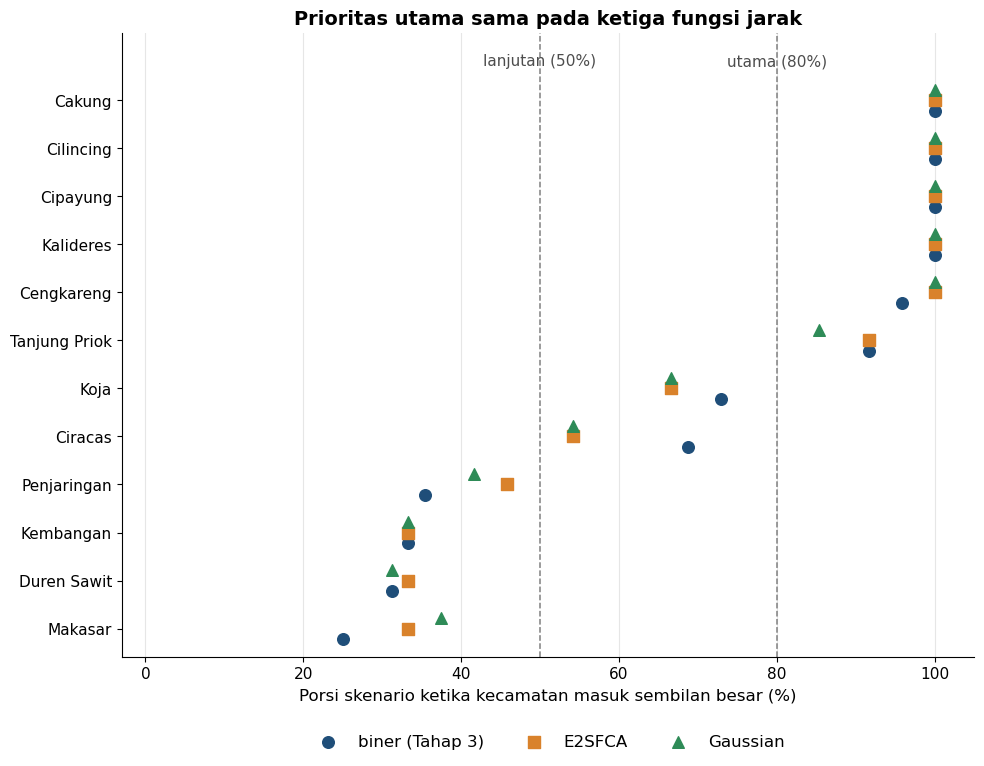


Interpretasi:
Varian biner menghasilkan akses dan frekuensi prioritas yang sama persis dengan Tahap 3 pada 48 skenario, sehingga perbedaan varian lain hanya berasal dari fungsi peluruhan jarak.
Dengan E2SFCA, prioritas utama adalah Cakung, Cengkareng, Cilincing, Cipayung, Kalideres, Tanjung Priok, sama dengan Tahap 3. Pada skenario utama, penduduk akses rendah 1.974.488 jiwa (18,0%), dibanding 1.766.634 jiwa pada varian biner; 8 dari 9 kecamatan sembilan besar sama, dan korelasi peringkat penduduk akses rendah per kecamatan ρ = 1,00. Cakupan sembilan simpul greedy 46,1% (biner 48,8%).
Dengan Gaussian, prioritas utama adalah Cakung, Cengkareng, Cilincing, Cipayung, Kalideres, Tanjung Priok, sama dengan Tahap 3. Pada skenario utama, penduduk akses rendah 1.996.504 jiwa (18,2%), dibanding 1.766.634 jiwa pada varian biner; 8 dari 9 kecamatan sembilan besar sama, dan korelasi peringkat penduduk akses rendah per kecamatan ρ = 1,00. Cakupan sembilan simpul greedy 45,7% (biner 48,8%).
Priorit

In [3]:
# ============ SEL 3: UJI B, 2SFCA DENGAN PELURUHAN JARAK ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
mulai4("peluruhan")
_EXP = math.exp(-0.5)
FUNGSI_BOBOT = {
    "biner (Tahap 3)": lambda d, d0: np.ones_like(d),
    "E2SFCA": lambda d, d0: np.select([d <= d0 / 3, d <= 2 * d0 / 3], [BOBOT_E2SFCA[0], BOBOT_E2SFCA[1]], BOBOT_E2SFCA[2]),
    "Gaussian": lambda d, d0: np.clip((np.exp(-0.5 * (d / d0) ** 2) - _EXP) / (1 - _EXP), 0.0, 1.0),
}
VAR_BINER = "biner (Tahap 3)"
_XY_LUAR = PIX_LUAR[["x", "y"]].to_numpy() if PIX_LUAR is not None else None
_KOSONG3 = (np.zeros(0, np.int64), np.zeros(0, np.int64), np.zeros(0))

def _pasangan_gl(xy_sumber, d0, tree, xy_tujuan):
    # pasangan (sumber, piksel, jarak garis lurus) dengan jarak <= d0
    li = tree.query_ball_point(xy_sumber, r=d0)
    lens = np.array([len(l) for l in li], dtype=np.int64)
    if lens.sum() == 0:
        return _KOSONG3
    idx = np.concatenate([np.asarray(l, dtype=np.int64) for l in li])
    src = np.repeat(np.arange(len(xy_sumber)), lens)
    return src, idx, np.hypot(xy_tujuan[idx, 0] - xy_sumber[src, 0], xy_tujuan[idx, 1] - xy_sumber[src, 1])

def pasangan_garis_lurus(xy_sumber, d0):
    dalam = _pasangan_gl(xy_sumber, d0, TREE_PIX, P_XY)
    luar = _pasangan_gl(xy_sumber, d0, TREE_LUAR, _XY_LUAR) if TREE_LUAR is not None else None
    return len(xy_sumber), dalam, luar

def akses_2sfca_bobot(pasang, pop, d0, fw, pop_luar=None):
    # 2SFCA berbobot jarak; pasang = (jumlah sumber, pasangan Jakarta, pasangan buffer luar)
    n_s, (src, idx, d), luar = pasang
    n = len(pop)
    if n_s == 0:
        return np.zeros(n), np.zeros(n)
    w = fw(d, d0)
    Pj = np.bincount(src, weights=pop[idx] * w, minlength=n_s)
    if luar is not None and pop_luar is not None and len(luar[0]):
        Pj = Pj + np.bincount(luar[0], weights=pop_luar[luar[1]] * fw(luar[2], d0), minlength=n_s)
    Rj = np.divide(1.0, Pj, out=np.zeros_like(Pj), where=Pj > 0)
    A = np.bincount(idx, weights=Rj[src] * w, minlength=n)
    n_in = np.bincount(idx, minlength=n).astype(float)
    return A, n_in

_DN = {}
def jarak_terdekat(sup):
    if sup not in _DN:
        sxy = _semua_xy(sup)
        _DN[sup] = cKDTree(sxy).query(P_XY)[0] if len(sxy) else np.full(len(P_XY), np.inf)
    return _DN[sup]

# ---- pemeriksaan: varian biner harus sama dengan Tahap 3 ----
_ps0 = pasangan_garis_lurus(_semua_xy(SUP_UTAMA), D0_UTAMA)
_Ab, _nb = akses_2sfca_bobot(_ps0, pop0, D0_UTAMA, FUNGSI_BOBOT[VAR_BINER], _PL)
assert np.allclose(_Ab, AKSES[(D0_UTAMA, SUP_UTAMA, POP_UTAMA_NAMA)][0], rtol=1e-9, atol=1e-15), "2SFCA biner berbeda dari Tahap 3."
assert np.array_equal(_nb, AKSES[(D0_UTAMA, SUP_UTAMA, POP_UTAMA_NAMA)][1]), "Jumlah aset dalam radius berbeda dari Tahap 3."

# ---- 48 skenario x 3 varian ----
_t = time.time()
SKEN4, UTAMA4 = [], {}
for d0 in D0_LIST:
    _lc = cakupan_calon(CALON_UTAMA, d0)
    for sup in SUP_STABIL:
        _ps = pasangan_garis_lurus(_semua_xy(sup), d0)
        _dn = jarak_terdekat(sup)
        for pnama, pcol in VARIAN_POP.items():
            _pop = PIX[pcol].to_numpy()
            for var, fw in FUNGSI_BOBOT.items():
                A, n_in = akses_2sfca_bobot(_ps, _pop, d0, fw, _PL)
                ak = agregat_kec(_pop, A, n_in, _dn)
                rendah, aref = akses_rendah(A, n_in, _pop)
                if (d0, sup, pnama) == (D0_UTAMA, SUP_UTAMA, POP_UTAMA_NAMA):
                    UTAMA4[var] = {"A": A, "n_in": n_in, "ak": ak, "rendah": rendah, "aref": aref}
                for keb in KEBUTUHAN:
                    kol = "akses_rendah_memadai" if keb == "data memadai" else "akses_rendah"
                    bobot = _pop * rendah * ((~TIPIS) if keb == "data memadai" else 1.0)
                    _, tam = mclp(_lc, bobot)
                    SKEN4.append({"varian": var, "d0": d0, "pasokan": sup, "penduduk": pnama, "kebutuhan": keb,
                                  "top": ak.nlargest(TOPK, kol)["kecamatan"].tolist(),
                                  "akses_rendah": float((_pop * rendah).sum()), "kebutuhan_total": float(bobot.sum()),
                                  "pct_mclp": float(sum(tam) / max(bobot.sum(), 1))})
print(f"{len(SKEN4)} skenario dihitung dalam {time.time() - _t:,.0f} detik")

FREK4 = {}
for var in FUNGSI_BOBOT:
    _sk = [s for s in SKEN4 if s["varian"] == var]
    _f = pd.Series(0.0, index=KEC_NAMA)
    for s in _sk:
        _f[s["top"]] += 1
    FREK4[var] = _f / len(_sk)
assert np.allclose(FREK4[VAR_BINER].reindex(KEC_NAMA).to_numpy(), FREK_TOP.reindex(KEC_NAMA).to_numpy()), \
    "Frekuensi varian biner berbeda dari Tahap 3."

TAB_PELURUHAN = pd.DataFrame({"kecamatan": KEC_NAMA})
for var in FUNGSI_BOBOT:
    TAB_PELURUHAN[f"frek_top9: {var}"] = TAB_PELURUHAN["kecamatan"].map(FREK4[var])
    TAB_PELURUHAN[f"status: {var}"] = TAB_PELURUHAN[f"frek_top9: {var}"].map(status_frek)
    _akv = UTAMA4[var]["ak"].set_index("kecamatan")
    TAB_PELURUHAN[f"akses_rendah_utama: {var}"] = TAB_PELURUHAN["kecamatan"].map(_akv[KOL_KEB])
_kf = [f"frek_top9: {v}" for v in FUNGSI_BOBOT]
TAB_PELURUHAN = TAB_PELURUHAN.sort_values(_kf[0], ascending=False).reset_index(drop=True)
TAB_PELURUHAN.round(4).to_csv(TAB4 / "tabel_prioritas_peluruhan_jarak.csv", index=False)

_rows = []
_top_b = set(UTAMA4[VAR_BINER]["ak"].nlargest(TOPK, KOL_KEB)["kecamatan"])
_kb = UTAMA4[VAR_BINER]["ak"].set_index("kecamatan")[KOL_KEB]
for var, u in UTAMA4.items():
    _akv = u["ak"].set_index("kecamatan")
    _top = u["ak"].nlargest(TOPK, KOL_KEB)["kecamatan"].tolist()
    _mc = [s["pct_mclp"] for s in SKEN4 if s["varian"] == var and s["d0"] == D0_UTAMA and s["pasokan"] == SUP_UTAMA
           and s["penduduk"] == POP_UTAMA_NAMA and s["kebutuhan"] == KEB_UTAMA][0]
    _rows.append({"varian": var, "akses_rendah_jiwa": float((pop0 * u["rendah"]).sum()),
                  "akses_rendah_pct": float((pop0 * u["rendah"]).sum() / pop0.sum()),
                  "akses_rendah_memadai_jiwa": float((pop0 * u["rendah"] * ~TIPIS).sum()),
                  "rasio_akses_maks_min": float(_akv["akses_per100rb"].max() / max(_akv["akses_per100rb"].min(), 1e-12)),
                  "kec_akses_terendah": _akv["akses_per100rb"].idxmin(), "kec_akses_tertinggi": _akv["akses_per100rb"].idxmax(),
                  "top9": "; ".join(_top), "irisan_top9_biner": len(set(_top) & _top_b),
                  "rho_kebutuhan_vs_biner": float(spearmanr(_akv[KOL_KEB].reindex(_kb.index), _kb)[0]),
                  "cakupan_mclp_greedy": _mc,
                  "prioritas_utama": "; ".join(TAB_PELURUHAN.loc[TAB_PELURUHAN[f"status: {var}"] == "Prioritas utama", "kecamatan"]),
                  "prioritas_lanjutan": "; ".join(TAB_PELURUHAN.loc[TAB_PELURUHAN[f"status: {var}"] == "Prioritas lanjutan", "kecamatan"])})
TAB_PELURUHAN_UTAMA = pd.DataFrame(_rows)
TAB_PELURUHAN_UTAMA.round(4).to_csv(TAB4 / "tabel_ringkas_peluruhan_jarak.csv", index=False)

print("\nFrekuensi masuk sembilan besar dari 48 skenario, per varian:")
_tampil = TAB_PELURUHAN[TAB_PELURUHAN[_kf].max(axis=1) >= 0.3]
print(_tampil[["kecamatan"] + _kf + [f"status: {v}" for v in FUNGSI_BOBOT]].round(3).to_string(index=False))
print("\nSkenario utama per varian:")
print(TAB_PELURUHAN_UTAMA.drop(columns=["top9"]).round(3).to_string(index=False))

# ---- gambar ----
_g = _tampil.sort_values(_kf[0]).reset_index(drop=True)
_gaya = {VAR_BINER: ("o", "#1f4e79"), "E2SFCA": ("s", "#d9822b"), "Gaussian": ("^", "#2e8b57")}
_geser = {VAR_BINER: -0.22, "E2SFCA": 0.0, "Gaussian": 0.22}
fig, ax = plt.subplots(figsize=(10, 0.5 * len(_g) + 1.8))
for var in FUNGSI_BOBOT:
    m, c = _gaya[var]
    ax.scatter(100 * _g[f"frek_top9: {var}"], np.arange(len(_g)) + _geser[var], marker=m, s=70, color=c, label=var, zorder=3)
for x_, t_ in ((50, "lanjutan (50%)"), (80, "utama (80%)")):
    ax.axvline(x_, color="0.5", ls="--", lw=1.1)
    ax.text(x_, len(_g) - 0.35, t_, ha="center", va="bottom", fontsize=11, color="0.3")
ax.set_yticks(np.arange(len(_g)))
ax.set_yticklabels(_g["kecamatan"])
ax.set_xlim(-3, 105)
ax.set_ylim(-0.6, len(_g) + 0.4)
ax.set_xlabel("Porsi skenario ketika kecamatan masuk sembilan besar (%)")
_pu = {v: set(TAB_PELURUHAN.loc[TAB_PELURUHAN[f"status: {v}"] == "Prioritas utama", "kecamatan"]) for v in FUNGSI_BOBOT}
_sama_semua = all(_pu[v] == _pu[VAR_BINER] for v in FUNGSI_BOBOT)
ax.set_title("Prioritas utama sama pada ketiga fungsi jarak" if _sama_semua else "Prioritas utama berubah menurut fungsi jarak",
             fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07 - 0.35 / max(len(_g), 1)), ncol=3, frameon=False)
ax.grid(axis="x", color="0.9")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
simpan4(fig, "U2_prioritas_peluruhan_jarak.png")
plt.show()

# ---- interpretasi ----
print("\nInterpretasi:")
catat4("peluruhan", f"Varian biner menghasilkan akses dan frekuensi prioritas yang sama persis dengan Tahap 3 pada {len(SKEN4) // 3} "
       "skenario, sehingga perbedaan varian lain hanya berasal dari fungsi peluruhan jarak.")
for var in FUNGSI_BOBOT:
    if var == VAR_BINER:
        continue
    _tambah, _hilang = sorted(_pu[var] - _pu[VAR_BINER]), sorted(_pu[VAR_BINER] - _pu[var])
    _r = TAB_PELURUHAN_UTAMA.set_index("varian").loc[var]
    _rb = TAB_PELURUHAN_UTAMA.set_index("varian").loc[VAR_BINER]
    _teks = f"Dengan {var}, prioritas utama adalah {', '.join(sorted(_pu[var])) or 'tidak ada'}"
    if not _tambah and not _hilang:
        _teks += ", sama dengan Tahap 3."
    else:
        _teks += ("; dibanding Tahap 3" + (f" bertambah {', '.join(_tambah)}" if _tambah else "")
                  + ("," if _tambah and _hilang else "") + (f" berkurang {', '.join(_hilang)}" if _hilang else "") + ".")
    _teks += (f" Pada skenario utama, penduduk akses rendah {fnum(_r['akses_rendah_jiwa'])} jiwa ({fpct(_r['akses_rendah_pct'])}), "
              f"dibanding {fnum(_rb['akses_rendah_jiwa'])} jiwa pada varian biner; {int(_r['irisan_top9_biner'])} dari {TOPK} "
              f"kecamatan sembilan besar sama, dan korelasi peringkat penduduk akses rendah per kecamatan ρ = "
              f"{fnum(_r['rho_kebutuhan_vs_biner'], 2)}. Cakupan sembilan simpul greedy {fpct(_r['cakupan_mclp_greedy'])} "
              f"(biner {fpct(_rb['cakupan_mclp_greedy'])}).")
    catat4("peluruhan", _teks)
_lanj = {v: set(TAB_PELURUHAN.loc[TAB_PELURUHAN[f"status: {v}"] == "Prioritas lanjutan", "kecamatan"]) for v in FUNGSI_BOBOT}
catat4("peluruhan", "Prioritas lanjutan per varian: " + "; ".join(f"{v}: {', '.join(sorted(s)) or 'tidak ada'}" for v, s in _lanj.items()) + ".")
RESULTS4["peluruhan"] = {"prioritas_utama": {v: sorted(s) for v, s in _pu.items()},
                         "prioritas_lanjutan": {v: sorted(s) for v, s in _lanj.items()},
                         "ringkas_utama": TAB_PELURUHAN_UTAMA.round(5).to_dict("records")}

## SEL 4: Jaringan jalan kaki OpenStreetMap

Uji C dan D membutuhkan jarak tempuh di jaringan jalan. Kita memakai jaringan `walk` dari osmnx (jalan dan jalur yang boleh dilalui pejalan kaki, tanpa jalan tol) untuk 42 kecamatan dan *buffer* 3,5 km, lalu menyimpannya sebagai tabel simpul dan ruas (parquet) supaya run berikutnya tidak mengunduh ulang. Unduhan pertama bisa memakan waktu belasan menit dan beberapa GB memori. Bila memori terbatas, `PENYANGGA_JARINGAN_M` di SEL 1 dapat diperkecil, dengan konsekuensi aset di bagian luar *buffer* tidak lagi terjangkau lewat jaringan pada uji D.

**Jalur cadangan bila Overpass gagal.** Gunakan ekstrak Geofabrik yang sama dengan Tahap 3, lalu saring ruas jalan (sekali saja):

```
cd data/raw
osmium extract -b 106.60,-6.45,107.05,-6.00 indonesia-latest.osm.pbf -o jakarta.osm.pbf --overwrite
osmium tags-filter jakarta.osm.pbf w/highway -o jalan_jakarta.osm --overwrite
```

Pada jalur cadangan, ruas yang dikecualikan filter `walk` osmnx (misalnya `motorway`, `cycleway`, `construction`, `foot=no`, dan `access=private`) ikut dibuang. Setiap piksel disambungkan ke simpul terdekat pada komponen jaringan terbesar, dan jarak dari pusat piksel ke simpul itu ikut dijumlahkan.

In [4]:
# ============ SEL 4: JARINGAN JALAN KAKI OSM ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
mulai4("jaringan")
_FN_SIMPUL, _FN_RUAS, _FN_META = (JARINGAN_DIR / "simpul.parquet", JARINGAN_DIR / "ruas.parquet",
                                  JARINGAN_DIR / "provenance.json")
_XML_CADANGAN = RAW / "jalan_jakarta.osm"
_POLA_BUANG = r"abandoned|bus_guideway|construction|cycleway|motor|planned|platform|proposed|raceway|razed|rest_area|services|^no$"

def _graf_ke_tabel(G):
    gn, ge = ox.graph_to_gdfs(G, nodes=True, edges=True)
    ge = ge.reset_index()
    simpul = pd.DataFrame({"osmid": gn.index.to_numpy(np.int64), "lon": gn["x"].to_numpy(float), "lat": gn["y"].to_numpy(float)})
    ruas = pd.DataFrame({"u": ge["u"].to_numpy(np.int64), "v": ge["v"].to_numpy(np.int64),
                         "panjang_m": ge["length"].to_numpy(float)})
    return simpul, ruas, ge

def muat_jaringan():
    if _FN_SIMPUL.exists() and _FN_RUAS.exists():
        meta = json.loads(_FN_META.read_text(encoding="utf-8")) if _FN_META.exists() else {}
        return pd.read_parquet(_FN_SIMPUL), pd.read_parquet(_FN_RUAS), meta.get("sumber", "cache"), meta
    if not HAS_OX:
        print("osmnx tidak terpasang; uji C dan D dilewati.")
        return None, None, None, {}
    ox.settings.use_cache = True
    ox.settings.requests_timeout = 900
    ox.settings.max_query_area_size = 1e8
    poly = gpd.GeoSeries([darat_m.buffer(PENYANGGA_JARINGAN_M)], crs=CRS_METRIC).to_crs(CRS_GEO).iloc[0]
    try:
        G = ox.graph_from_polygon(poly, network_type="walk", simplify=True, retain_all=False)
        simpul, ruas, _ = _graf_ke_tabel(G)
        sumber = f"Overpass melalui osmnx {ox.__version__} (network_type walk)"
    except Exception as e:
        print(f"Unduhan Overpass gagal ({type(e).__name__}: {str(e)[:120]})")
        if not _XML_CADANGAN.exists():
            print(f"Berkas cadangan {_XML_CADANGAN.relative_to(BASE)} belum ada; uji C dan D dilewati.")
            return None, None, None, {}
        _tags = list(ox.settings.useful_tags_way)
        for _k in ("foot", "access", "area", "service"):
            if _k not in _tags:
                _tags.append(_k)
        ox.settings.useful_tags_way = _tags
        # ruas disaring sebelum penyederhanaan supaya ruas terlarang tidak tergabung dengan ruas lain
        G = ox.graph_from_xml(_XML_CADANGAN, bidirectional=True, simplify=False, retain_all=True)
        ge = ox.graph_to_gdfs(G, nodes=False).reset_index()
        teks = lambda c: (ge[c].map(lambda v: "|".join(map(str, v)) if isinstance(v, list) else str(v))
                          if c in ge.columns else pd.Series("", index=ge.index))
        buang = (teks("highway").str.contains(_POLA_BUANG, regex=True) | teks("foot").str.fullmatch("no")
                 | teks("access").str.contains("private") | teks("service").str.contains("private")
                 | teks("area").str.contains("yes"))
        G.remove_edges_from(list(zip(ge.loc[buang, "u"], ge.loc[buang, "v"], ge.loc[buang, "key"])))
        G = ox.simplify_graph(ox.truncate.largest_component(G, strongly=False))
        simpul, ruas, _ = _graf_ke_tabel(G)
        sumber = f"{_XML_CADANGAN.name} (Geofabrik, disaring setara network_type walk)"
    meta = {"sumber": sumber, "diakses_utc": datetime.now(timezone.utc).isoformat(),
            "penyangga_m": PENYANGGA_JARINGAN_M, "n_simpul": int(len(simpul)), "n_ruas": int(len(ruas))}
    JARINGAN_DIR.mkdir(parents=True, exist_ok=True)
    simpul.to_parquet(_FN_SIMPUL, index=False)
    ruas.to_parquet(_FN_RUAS, index=False)
    _FN_META.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
    return simpul, ruas, sumber, meta

JARINGAN_OK = False
if HITUNG_JARINGAN:
    _t = time.time()
    SIMPUL, RUAS, SUMBER_JARINGAN, META_JARINGAN = muat_jaringan()
    JARINGAN_OK = SIMPUL is not None and len(RUAS) > 0
    print(f"Jaringan dimuat dalam {time.time() - _t:,.0f} detik" if JARINGAN_OK else "Jaringan tidak tersedia.")

if JARINGAN_OK:
    _id = pd.Index(SIMPUL["osmid"].to_numpy())
    _u, _v = _id.get_indexer(RUAS["u"].to_numpy()), _id.get_indexer(RUAS["v"].to_numpy())
    _ok = (_u >= 0) & (_v >= 0) & (_u != _v)
    _e = (pd.DataFrame({"a": np.minimum(_u, _v)[_ok], "b": np.maximum(_u, _v)[_ok],
                        "w": np.maximum(RUAS["panjang_m"].to_numpy(float)[_ok], 0.1)})
          .groupby(["a", "b"], as_index=False)["w"].min())      # ruas paralel & dua arah -> satu ruas terpendek
    N_SIMPUL = len(SIMPUL)
    G_CSR = sparse.csr_matrix((_e["w"].to_numpy(), (_e["a"].to_numpy(), _e["b"].to_numpy())), shape=(N_SIMPUL, N_SIMPUL))
    _sx, _sy = Transformer.from_crs(CRS_GEO, CRS_METRIC, always_xy=True).transform(SIMPUL["lon"].to_numpy(), SIMPUL["lat"].to_numpy())
    XY_SIMPUL = np.c_[_sx, _sy]
    _nk, _lab = connected_components(G_CSR, directed=False)
    _besar = np.bincount(_lab).argmax()
    IDX_KOMPONEN = np.nonzero(_lab == _besar)[0]
    TREE_SIMPUL = cKDTree(XY_SIMPUL[IDX_KOMPONEN])

    def sambung(xy):
        # jarak ke simpul terdekat pada komponen terbesar dan indeks simpulnya
        d, k = TREE_SIMPUL.query(xy)
        return d, IDX_KOMPONEN[k]

    SNAP_PIX, NODE_PIX = sambung(P_XY)
    SNAP_LUAR, NODE_LUAR = sambung(_XY_LUAR) if _XY_LUAR is not None else (None, None)
    _snap_med = median_berbobot(SNAP_PIX, pop0)
    _snap_jauh = float((pop0 * (SNAP_PIX > 200)).sum() / pop0.sum())
    print(f"Sumber: {SUMBER_JARINGAN}")
    print(f"Simpul {fnum(N_SIMPUL)} | ruas {fnum(len(_e))} | panjang {fnum(_e['w'].sum() / 1000, 0)} km | "
          f"komponen {fnum(_nk)} (terbesar {fnum(len(IDX_KOMPONEN))} simpul)")
    print(f"Jarak piksel ke simpul terdekat: median berbobot penduduk {fnum(_snap_med, 0)} m; "
          f"penduduk dengan jarak sambung > 200 m: {fpct(_snap_jauh)}")
    print("\nInterpretasi:")
    catat4("jaringan", f"Jaringan jalan kaki ({SUMBER_JARINGAN}) memuat {fnum(len(_e))} ruas sepanjang "
           f"{fnum(_e['w'].sum() / 1000, 0)} km di 42 kecamatan dan buffer {fnum(PENYANGGA_JARINGAN_M)} m. "
           f"Separuh penduduk tinggal dalam {fnum(_snap_med, 0)} m dari simpul jaringan"
           + (f", dan {fpct(_snap_jauh)} penduduk berjarak lebih dari 200 m dari simpul terdekat, sehingga jarak jaringan di "
              "kawasan itu kurang presisi." if _snap_jauh >= 0.01 else "; hampir semua piksel tersambung dekat ke jaringan."))
    RESULTS4["jaringan"] = {"sumber": SUMBER_JARINGAN, "meta": META_JARINGAN, "n_ruas": int(len(_e)),
                            "panjang_km": float(_e["w"].sum() / 1000), "snap_median_m": float(_snap_med),
                            "pct_snap_lebih_200m": _snap_jauh}

Unduhan Overpass gagal (ChunkedEncodingError: Response ended prematurely)
Berkas cadangan data/raw/jalan_jakarta.osm belum ada; uji C dan D dilewati.
Jaringan tidak tersedia.


## SEL 5: Uji C, kelayakan transit dengan jarak jaringan

Tahap 3 menghitung porsi penduduk yang tinggal dalam 400 m dari halte dan 800 m dari stasiun dengan jarak garis lurus. Ambang 400 m dan 800 m lazim dipakai sebagai jangkauan berjalan kaki ke bus dan kereta (El-Geneidy dkk., 2014), tetapi *buffer* garis lurus cenderung melebihkan cakupan dibanding jarak jaringan (Gutiérrez dan García-Palomares, 2008). Di sel ini ambang yang sama diukur dengan jarak jaringan jalan kaki untuk seluruh penduduk, penduduk akses rendah, kecamatan prioritas, dan sembilan lokasi usulan.

Jarak ke halte terdekat dihitung sekali untuk semua simpul dengan Dijkstra multi-sumber: setiap halte dijadikan simpul tambahan yang terhubung ke simpul jaringan terdekat. Halte yang dipakai adalah titik halte dan terminal bus di OSM (Tahap 1), sehingga pemberhentian angkutan pengumpan yang tidak bertitik tetap belum terwakili.

In [5]:
# ============ SEL 5: UJI C, TRANSIT DENGAN JARAK JARINGAN ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
mulai4("transit")
if not JARINGAN_OK:
    print("Jaringan jalan kaki tidak tersedia; uji C dilewati.")
else:
    def jarak_jaringan_ke_titik(xy_tujuan, batas):
        # jarak jaringan setiap simpul ke titik tujuan terdekat, termasuk jarak sambung titik tujuan
        d_s, n_s = sambung(xy_tujuan)
        m, n = len(xy_tujuan), N_SIMPUL
        _tambah = sparse.csr_matrix((np.maximum(d_s, 0.1), (np.arange(n, n + m), n_s)), shape=(n + m, n + m))
        G_aug = (sparse.bmat([[G_CSR, None], [None, sparse.csr_matrix((m, m))]], format="csr") + _tambah).tocsr()
        dist = dijkstra(G_aug, directed=False, indices=np.arange(n, n + m), min_only=True, limit=batas)
        return dist[:n]

    _t = time.time()
    DIST_HALTE_SIMPUL = jarak_jaringan_ke_titik(XY_HALTE, np.inf)
    DIST_STASIUN_SIMPUL = jarak_jaringan_ke_titik(XY_STASIUN, np.inf)
    D_HALTE_NET = DIST_HALTE_SIMPUL[NODE_PIX] + SNAP_PIX
    D_STASIUN_NET = DIST_STASIUN_SIMPUL[NODE_PIX] + SNAP_PIX
    print(f"Dijkstra multi-sumber selesai dalam {time.time() - _t:,.1f} detik")

    def _porsi(mask, w):
        return float((w * mask).sum() / max(w.sum(), 1))

    _prior = AK.loc[AK["status"].isin(["Prioritas utama", "Prioritas lanjutan"]), "kecamatan"].tolist()
    _kelompok = [("Seluruh penduduk", pop0), ("Penduduk akses rendah", _keb0)]
    _kelompok += [(k, _keb0 * (KEC_I == KEC_NAMA.index(k))) for k in _prior]
    _rows = []
    for nama_k, w in _kelompok:
        _rows.append({"kelompok": nama_k, "jiwa": float(w.sum()),
                      "halte_garis_lurus": _porsi(D_HALTE <= BATAS_HALTE_M, w),
                      "halte_jaringan": _porsi(D_HALTE_NET <= BATAS_HALTE_M, w),
                      "stasiun_garis_lurus": _porsi(D_STASIUN <= BATAS_STASIUN_M, w),
                      "stasiun_jaringan": _porsi(D_STASIUN_NET <= BATAS_STASIUN_M, w)})
    TAB_TRANSIT = pd.DataFrame(_rows)
    TAB_TRANSIT["selisih_halte_pp"] = 100 * (TAB_TRANSIT["halte_jaringan"] - TAB_TRANSIT["halte_garis_lurus"])
    TAB_TRANSIT["selisih_stasiun_pp"] = 100 * (TAB_TRANSIT["stasiun_jaringan"] - TAB_TRANSIT["stasiun_garis_lurus"])
    TAB_TRANSIT.round(4).to_csv(TAB4 / "tabel_transit_jarak_jaringan.csv", index=False)

    _ok_r = (D_HALTE >= 100) & np.isfinite(D_HALTE_NET)
    DETOUR_HALTE = median_berbobot(D_HALTE_NET[_ok_r] / D_HALTE[_ok_r], pop0[_ok_r])
    DETOUR_HALTE_RENDAH = median_berbobot(D_HALTE_NET[_ok_r] / D_HALTE[_ok_r], _keb0[_ok_r])

    _xy_lok = LOKASI[["x", "y"]].to_numpy()
    _ds, _ns = sambung(_xy_lok)
    TAB_SIMPUL_TRANSIT = pd.DataFrame({
        "urutan": LOKASI["urutan"], "lokasi": LOKASI.get("nama_tampil", LOKASI["nama"]), "kecamatan": LOKASI["kecamatan"],
        "halte_garis_lurus_m": LOKASI["jarak_halte_m"], "halte_jaringan_m": DIST_HALTE_SIMPUL[_ns] + _ds,
        "stasiun_garis_lurus_m": LOKASI["jarak_stasiun_m"], "stasiun_jaringan_m": DIST_STASIUN_SIMPUL[_ns] + _ds})
    TAB_SIMPUL_TRANSIT.round(0).to_csv(TAB4 / "tabel_simpul_transit_jarak_jaringan.csv", index=False)

    print("\nPorsi penduduk dalam ambang jarak (garis lurus vs jaringan):")
    print(TAB_TRANSIT.assign(**{c: TAB_TRANSIT[c].map(fpct) for c in
                                ("halte_garis_lurus", "halte_jaringan", "stasiun_garis_lurus", "stasiun_jaringan")})
          .round({"jiwa": 0, "selisih_halte_pp": 1, "selisih_stasiun_pp": 1}).to_string(index=False))
    print("\nJarak lokasi usulan ke halte dan stasiun (m):")
    print(TAB_SIMPUL_TRANSIT.round(0).to_string(index=False))

    # ---- gambar ----
    _g = TAB_TRANSIT.iloc[::-1].reset_index(drop=True)
    _y = np.arange(len(_g))
    fig, ax = plt.subplots(figsize=(10.5, 0.62 * len(_g) + 1.8))
    ax.barh(_y + 0.19, 100 * _g["halte_garis_lurus"], height=0.36, color="#9fb7d0", label="Garis lurus (Tahap 3)")
    ax.barh(_y - 0.19, 100 * _g["halte_jaringan"], height=0.36, color="#1f4e79", label="Jaringan jalan kaki")
    for i, r in _g.iterrows():
        ax.text(100 * r["halte_garis_lurus"] + 1, i + 0.19, fpct(r["halte_garis_lurus"], 0), va="center", fontsize=11)
        ax.text(100 * r["halte_jaringan"] + 1, i - 0.19, fpct(r["halte_jaringan"], 0), va="center", fontsize=11,
                fontweight="bold")
    ax.set_yticks(_y)
    ax.set_yticklabels(_g["kelompok"])
    ax.set_xlim(0, 112)
    ax.set_xlabel(f"Porsi penduduk dalam {BATAS_HALTE_M} m dari halte (%)")
    _rk = TAB_TRANSIT.set_index("kelompok").loc["Penduduk akses rendah"]
    ax.set_title(f"Penduduk akses rendah dekat halte: {fpct(_rk['halte_garis_lurus'])} (garis lurus), "
                 f"{fpct(_rk['halte_jaringan'])} (jaringan)", fontsize=14)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07 - 0.3 / len(_g)), ncol=2, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    simpan4(fig, "U3_transit_jarak_jaringan.png")
    plt.show()

    # ---- interpretasi ----
    print("\nInterpretasi:")
    _rs = TAB_TRANSIT.set_index("kelompok").loc["Seluruh penduduk"]
    catat4("transit", f"Dengan jarak jaringan jalan kaki, {fpct(_rk['halte_jaringan'])} penduduk akses rendah tinggal dalam "
           f"{BATAS_HALTE_M} m dari halte, dibanding {fpct(_rk['halte_garis_lurus'])} dengan jarak garis lurus "
           f"({arah_pp(_rk['selisih_halte_pp'])}). Untuk seluruh penduduk angkanya {fpct(_rs['halte_jaringan'])} "
           f"berbanding {fpct(_rs['halte_garis_lurus'])}. Porsi penduduk akses rendah dalam {BATAS_STASIUN_M} m dari stasiun "
           f"menjadi {fpct(_rk['stasiun_jaringan'])} (garis lurus {fpct(_rk['stasiun_garis_lurus'])}).")
    catat4("transit", f"Median rasio jarak jaringan terhadap jarak garis lurus ke halte terdekat adalah {fnum(DETOUR_HALTE, 2)} "
           f"untuk seluruh penduduk dan {fnum(DETOUR_HALTE_RENDAH, 2)} untuk penduduk akses rendah"
           + (", sehingga angka garis lurus di Tahap 3 dibaca sebagai batas atas." if _rk["selisih_halte_pp"] < -0.5 else "."))
    _pk = TAB_TRANSIT[~TAB_TRANSIT["kelompok"].isin(["Seluruh penduduk", "Penduduk akses rendah"])].sort_values("halte_jaringan")
    catat4("transit", "Porsi penduduk akses rendah dalam 400 m jaringan dari halte di kecamatan prioritas: "
           + "; ".join(f"{r.kelompok} {fpct(r.halte_jaringan, 0)} (garis lurus {fpct(r.halte_garis_lurus, 0)})"
                       for r in _pk.itertuples()) + ".")
    _jauh = TAB_SIMPUL_TRANSIT[TAB_SIMPUL_TRANSIT["halte_jaringan_m"] > BATAS_HALTE_M]
    catat4("transit", f"Sebanyak {len(_jauh)} dari {len(TAB_SIMPUL_TRANSIT)} lokasi usulan berjarak jaringan lebih dari "
           f"{BATAS_HALTE_M} m dari halte"
           + (": " + "; ".join(f"{r.lokasi} di {r.kecamatan} ({fnum(r.halte_jaringan_m, 0)} m)" for r in _jauh.itertuples())
              if len(_jauh) else "") + ".")
    RESULTS4["transit"] = {"tabel": TAB_TRANSIT.round(5).to_dict("records"), "detour_median": float(DETOUR_HALTE),
                           "detour_median_akses_rendah": float(DETOUR_HALTE_RENDAH),
                           "simpul": TAB_SIMPUL_TRANSIT.round(1).to_dict("records")}

Jaringan jalan kaki tidak tersedia; uji C dilewati.


## SEL 6: Uji D, 2SFCA dengan jarak jaringan

Sel ini menghitung ulang skenario utama (radius 1.500 m, ruang kreatif publik gabungan, penduduk terkalibrasi) dengan jarak jaringan jalan kaki. Pasangan sumber–piksel disaring dulu dengan jarak garis lurus. Jarak jaringan tidak mungkin lebih pendek daripada jarak garis lurus, sehingga penyaringan ini tidak membuang pasangan yang sah. Dijkstra dijalankan per blok sumber dengan batas $d_0$ supaya memori tetap terkendali.

Jangkauan kandidat lokasi Simpul Kreatif juga dihitung dengan jarak jaringan, lalu MCLP dijalankan dengan greedy dan secara eksak. Penduduk akses rendah dilaporkan dengan dua ambang: ambang yang dihitung ulang dari median akses versi jaringan, dan ambang Tahap 3 supaya besaran absolutnya dapat dibandingkan.

In [6]:
# ============ SEL 6: UJI D, 2SFCA DENGAN JARAK JARINGAN ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
mulai4("akses_jaringan")
if not JARINGAN_OK:
    print("Jaringan jalan kaki tidak tersedia; uji D dilewati.")
else:
    def pasangan_jaringan(xy_sumber, d0, sasaran):
        # sasaran: daftar (tree, xy, simpul, jarak sambung); keluaran per sasaran: (sumber, piksel, jarak jaringan) <= d0
        d_s, n_s = sambung(xy_sumber)
        daftar = [t.query_ball_point(xy_sumber, r=d0) for (t, _, _, _) in sasaran]
        uniq, inv = np.unique(n_s, return_inverse=True)
        k = max(1, int(MEMORI_DIJKSTRA // (8 * N_SIMPUL)))
        kumpul = [([], [], []) for _ in sasaran]
        for a in range(0, len(uniq), k):
            blok = uniq[a:a + k]
            D = dijkstra(G_CSR, directed=False, indices=blok, limit=d0)
            for s in np.nonzero((inv >= a) & (inv < a + len(blok)))[0]:
                baris_d = D[inv[s] - a]
                for ti, (_, _, simpul_t, snap_t) in enumerate(sasaran):
                    cand = np.asarray(daftar[ti][s], dtype=np.int64)
                    if len(cand) == 0:
                        continue
                    dd = baris_d[simpul_t[cand]] + snap_t[cand] + d_s[s]
                    ok = dd <= d0
                    if ok.any():
                        kumpul[ti][0].append(np.full(int(ok.sum()), s, dtype=np.int64))
                        kumpul[ti][1].append(cand[ok])
                        kumpul[ti][2].append(dd[ok])
        return [(np.concatenate(a_), np.concatenate(b_), np.concatenate(c_)) if a_ else _KOSONG3 for a_, b_, c_ in kumpul]

    def daftar_per_sumber(pasang, n_sumber):
        src, idx, _ = pasang
        o = np.argsort(src, kind="stable")
        return np.split(idx[o], np.searchsorted(src[o], np.arange(1, n_sumber)))

    _sasaran = [(TREE_PIX, P_XY, NODE_PIX, SNAP_PIX)]
    if TREE_LUAR is not None:
        _sasaran.append((TREE_LUAR, _XY_LUAR, NODE_LUAR, SNAP_LUAR))
    _t = time.time()
    _sxy = _semua_xy(SUP_UTAMA)
    _pj = pasangan_jaringan(_sxy, D0_UTAMA, _sasaran)
    PASANG_NET = (len(_sxy), _pj[0], _pj[1] if len(_pj) > 1 else None)
    _cal_xy = CALON[CALON_UTAMA][["x", "y"]].to_numpy()
    LC_NET = daftar_per_sumber(pasangan_jaringan(_cal_xy, D0_UTAMA, _sasaran[:1])[0], len(_cal_xy))
    print(f"Pasangan jarak jaringan: {fnum(len(_pj[0][0]))} pasangan aset–piksel dari {fnum(len(_sxy))} aset; "
          f"waktu {time.time() - _t:,.0f} detik")

    A_NET, NIN_NET = akses_2sfca_bobot(PASANG_NET, pop0, D0_UTAMA, FUNGSI_BOBOT[VAR_BINER], _PL)
    DN_NET = np.full(len(P_XY), np.inf)
    np.minimum.at(DN_NET, PASANG_NET[1][1], PASANG_NET[1][2])
    RENDAH_NET, AREF_NET = akses_rendah(A_NET, NIN_NET, pop0)
    RENDAH_NET_TETAP = (NIN_NET == 0) | (A_NET < AMBANG_RENDAH * A_REF0)
    AK_NET = agregat_kec(pop0, A_NET, NIN_NET, DN_NET)
    _rendah0, _ = akses_rendah(A0, NIN0, pop0)

    # ---- MCLP dengan jangkauan jaringan ----
    _bobot_net = pop0 * RENDAH_NET * ((~TIPIS) if KEB_UTAMA == "data memadai" else 1.0)
    _pg_net, _tg_net = mclp(LC_NET, _bobot_net)
    _Cn, _Wn = matriks_cakupan(LC_NET, _bobot_net)
    _pe_net, _ne_net, _res_net = mclp_eksak(_Cn, _Wn, TOPK)
    _terlayani = np.zeros(len(pop0), bool)
    for j in PILIH_GREEDY[:TOPK]:
        _terlayani[LC_NET[j]] = True
    _lama_di_net = float((_bobot_net * _terlayani).sum() / max(_bobot_net.sum(), 1))

    # ---- tabel ----
    _ke = AK.set_index("kecamatan")
    _kn = AK_NET.set_index("kecamatan")
    TAB_AKSES_NET = pd.DataFrame({
        "akses_per100rb_garis_lurus": _ke["akses_per100rb"], "akses_per100rb_jaringan": _kn["akses_per100rb"],
        "akses_rendah_garis_lurus": _ke[KOL_KEB], "akses_rendah_jaringan": _kn[KOL_KEB],
        "akses_rendah_jaringan_ambang_tahap3": pd.Series(np.bincount(KEC_I, weights=pop0 * RENDAH_NET_TETAP * ~TIPIS,
                                                                     minlength=nK), index=KEC_NAMA),
        "status_tahap3": _ke["status"]}).reindex(KEC_NAMA)
    TAB_AKSES_NET.index.name = "kecamatan"
    TAB_AKSES_NET["peringkat_garis_lurus"] = TAB_AKSES_NET["akses_rendah_garis_lurus"].rank(ascending=False, method="first").astype(int)
    TAB_AKSES_NET["peringkat_jaringan"] = TAB_AKSES_NET["akses_rendah_jaringan"].rank(ascending=False, method="first").astype(int)
    TAB_AKSES_NET = TAB_AKSES_NET.sort_values("peringkat_jaringan")
    TAB_AKSES_NET.reset_index().round(3).to_csv(TAB4 / "tabel_akses_jarak_jaringan.csv", index=False)
    _top_e = set(TAB_AKSES_NET.nsmallest(TOPK, "peringkat_garis_lurus").index)
    _top_n = set(TAB_AKSES_NET.nsmallest(TOPK, "peringkat_jaringan").index)
    _rho_n = spearmanr(TAB_AKSES_NET["akses_rendah_garis_lurus"], TAB_AKSES_NET["akses_rendah_jaringan"])[0]
    _pu3 = set(RESULTS["akses"]["prioritas_stabil"])
    RINGKAS_NET = {
        "median_akses_garis_lurus": float(A_REF0 * 1e5), "median_akses_jaringan": float(AREF_NET * 1e5),
        "akses_rendah_garis_lurus": float((pop0 * _rendah0).sum()), "akses_rendah_jaringan": float((pop0 * RENDAH_NET).sum()),
        "akses_rendah_jaringan_ambang_tahap3": float((pop0 * RENDAH_NET_TETAP).sum()),
        "tanpa_ruang_garis_lurus": float((pop0 * (NIN0 == 0)).sum()), "tanpa_ruang_jaringan": float((pop0 * (NIN_NET == 0)).sum()),
        "irisan_top9": len(_top_e & _top_n), "rho_kecamatan": float(_rho_n),
        "prioritas_utama_di_top9_jaringan": sorted(_pu3 & _top_n), "prioritas_utama_keluar": sorted(_pu3 - _top_n),
        "masuk_top9_jaringan": sorted(_top_n - _top_e),
        "mclp_greedy_jaringan": float(sum(_tg_net) / max(_bobot_net.sum(), 1)),
        "mclp_eksak_jaringan": float(_ne_net / max(_bobot_net.sum(), 1)), "status_solver": int(_res_net.status),
        "lokasi_tahap3_dengan_jaringan": _lama_di_net,
        "lokasi_sama_dengan_tahap3": len(set(_pg_net) & set(PILIH_GREEDY[:TOPK]))}
    print(f"Median akses kota: {fnum(RINGKAS_NET['median_akses_garis_lurus'], 1)} (garis lurus) vs "
          f"{fnum(RINGKAS_NET['median_akses_jaringan'], 1)} (jaringan) ruang per 100.000 penduduk")
    print(TAB_AKSES_NET.head(12).round(1).to_string())

    # ---- gambar ----
    _g = TAB_AKSES_NET[(TAB_AKSES_NET["peringkat_jaringan"] <= 12) | (TAB_AKSES_NET["peringkat_garis_lurus"] <= 12)]
    _g = _g.sort_values("akses_rendah_jaringan").reset_index()
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(_g) + 1.8))
    for i, r in _g.iterrows():
        ax.plot([r["akses_rendah_garis_lurus"] / 1e3, r["akses_rendah_jaringan"] / 1e3], [i, i], color="0.75", lw=2, zorder=1)
    ax.scatter(_g["akses_rendah_garis_lurus"] / 1e3, _g.index, s=70, color="#9fb7d0", edgecolor="#1f4e79",
               label="Garis lurus (Tahap 3)", zorder=2)
    ax.scatter(_g["akses_rendah_jaringan"] / 1e3, _g.index, s=70, color="#1f4e79", label="Jaringan jalan kaki", zorder=3)
    ax.set_yticks(_g.index)
    ax.set_yticklabels([f"{k}{' *' if k in _pu3 else ''}" for k in _g["kecamatan"]])
    ax.set_xlabel("Penduduk akses rendah di sel data memadai (ribu jiwa)")
    ax.set_title(f"{RINGKAS_NET['irisan_top9']} dari {TOPK} kecamatan sembilan besar sama pada kedua ukuran jarak", fontsize=14)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07 - 0.3 / len(_g)), ncol=2, frameon=False)
    ax.grid(axis="x", color="0.92")
    ax.spines[["top", "right"]].set_visible(False)
    fig.text(0.01, -0.02, "* prioritas utama Tahap 3. Ambang akses rendah dihitung ulang dari median akses versi jaringan.",
             fontsize=10, color="0.35")
    plt.tight_layout()
    simpan4(fig, "U4_akses_jarak_jaringan.png")
    plt.show()

    # ---- interpretasi ----
    print("\nInterpretasi:")
    R = RINGKAS_NET
    catat4("akses_jaringan", f"Dengan jarak jaringan jalan kaki, median akses kota menjadi {fnum(R['median_akses_jaringan'], 1)} "
           f"ruang kreatif publik per 100.000 penduduk (garis lurus {fnum(R['median_akses_garis_lurus'], 1)}). Penduduk tanpa satu "
           f"pun ruang kreatif publik dalam {fnum(D0_UTAMA)} m bertambah dari {fnum(R['tanpa_ruang_garis_lurus'])} menjadi "
           f"{fnum(R['tanpa_ruang_jaringan'])} jiwa.")
    catat4("akses_jaringan", f"Penduduk akses rendah menjadi {fnum(R['akses_rendah_jaringan'])} jiwa bila ambang dihitung ulang "
           f"(garis lurus {fnum(R['akses_rendah_garis_lurus'])}), atau {fnum(R['akses_rendah_jaringan_ambang_tahap3'])} jiwa bila "
           "ambang Tahap 3 dipertahankan.")
    catat4("akses_jaringan", f"Sebanyak {R['irisan_top9']} dari {TOPK} kecamatan sembilan besar sama pada kedua ukuran jarak, dan "
           f"korelasi peringkat penduduk akses rendah per kecamatan ρ = {fnum(R['rho_kecamatan'], 2)}. "
           + (f"Semua prioritas utama Tahap 3 tetap masuk sembilan besar versi jaringan."
              if not R["prioritas_utama_keluar"] else
              f"Prioritas utama Tahap 3 yang keluar dari sembilan besar versi jaringan: {', '.join(R['prioritas_utama_keluar'])}.")
           + (f" Kecamatan yang baru masuk: {', '.join(R['masuk_top9_jaringan'])}." if R["masuk_top9_jaringan"] else ""))
    catat4("akses_jaringan", f"Dengan jangkauan jaringan, sembilan simpul greedy menjangkau {fpct(R['mclp_greedy_jaringan'])} "
           f"penduduk akses rendah dan solusi eksak {fpct(R['mclp_eksak_jaringan'])}. Sembilan lokasi Tahap 3, bila jangkauannya "
           f"diukur dengan jaringan, menjangkau {fpct(R['lokasi_tahap3_dengan_jaringan'])}; {R['lokasi_sama_dengan_tahap3']} dari "
           f"{TOPK} lokasi greedy versi jaringan sama dengan lokasi Tahap 3.")
    RESULTS4["akses_jaringan"] = R

Jaringan jalan kaki tidak tersedia; uji D dilewati.


## SEL 7: Uji E, keragaman dengan bilangan Hill

Entropi Shannon adalah satu anggota keluarga ukuran keragaman. Yue dkk. (2017) menyarankan bilangan Hill (Hill, 1973) karena memisahkan tiga hal: orde 0 adalah kekayaan kategori, orde 1 adalah eksponen entropi Shannon, dan orde 2 adalah kebalikan indeks Simpson yang menekankan kategori dominan. Ketiganya dirarefaksi ke ukuran sampel yang sama dengan Tahap 3 (40 aset per klaster DBSCAN, 100 aset Overture per kecamatan). Orde 0 memakai rumus Hurlbert (1971), sedangkan orde 1 dan 2 dirata-ratakan dari subsampel acak.

Yang diuji adalah dua klaim di naskah: klaster yang lebih besar cenderung kurang beragam, dan klaster Menteng paling beragam.

In [7]:
# ============ SEL 7: UJI E, BILANGAN HILL ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
mulai4("hill")

def hill_raref(kode, n, iters, rng):
    kode = np.asarray(kode, int)
    if len(kode) < n:
        return (np.nan, np.nan, np.nan)
    q0 = raref_kekayaan(np.bincount(kode, minlength=K_KAT), n)
    q1, q2 = np.empty(iters), np.empty(iters)
    for t in range(iters):
        c = np.bincount(rng.choice(kode, n, replace=False), minlength=K_KAT)
        p = c[c > 0] / n
        q1[t], q2[t] = math.exp(-(p * np.log(p)).sum()), 1.0 / (p ** 2).sum()
    return (float(q0), float(q1.mean()), float(q2.mean()))

# ---- klaster DBSCAN ----
_rows = []
for r in KLASTER[KLASTER["n_aset"] >= RAREF_N_KLASTER].itertuples():
    q0, q1, q2 = hill_raref(poi.loc[poi["klaster"] == r.klaster, "kat_kode"].to_numpy(), RAREF_N_KLASTER, RAREF_ITER, RNG4)
    _rows.append({"klaster": r.klaster, "kecamatan_utama": r.kecamatan_utama, "n_aset": r.n_aset,
                  "entropi_raref40": r.entropi_raref40, "hill_q0": q0, "hill_q1": q1, "hill_q2": q2})
TAB_HILL_KLASTER = pd.DataFrame(_rows)
TAB_HILL_KLASTER.round(4).to_csv(TAB4 / "tabel_hill_klaster.csv", index=False)
_ukuran = ["entropi_raref40", "hill_q0", "hill_q1", "hill_q2"]
_nama_uk = {"entropi_raref40": "entropi Shannon", "hill_q0": "Hill orde 0", "hill_q1": "Hill orde 1", "hill_q2": "Hill orde 2"}
RHO_HILL = {u: float(spearmanr(TAB_HILL_KLASTER["n_aset"], TAB_HILL_KLASTER[u])[0]) for u in _ukuran}
TERATAS = {u: TAB_HILL_KLASTER.loc[TAB_HILL_KLASTER[u].idxmax(), "kecamatan_utama"] for u in _ukuran}

# ---- kecamatan, Overture ----
_ov = ovt[ovt["kreatif"]].copy()
_ov["kat_kode"] = _ov["sub_ovt"].map(KAT_ENT).map(KODE)
_rows = []
for k in KEC_NAMA:
    q0, q1, q2 = hill_raref(_ov.loc[_ov["kecamatan"] == k, "kat_kode"].dropna().to_numpy(), RAREF_N_OVT, 300, RNG4)
    _rows.append({"kecamatan": k, "hill_q0": q0, "hill_q1": q1, "hill_q2": q2})
TAB_HILL_KEC = pd.DataFrame(_rows).merge(ENT[["kecamatan", "n_aset_ovt", "pangsa_nonkul_ovt", "entropi_raref_ovt", "status_ragam_ovt"]],
                                         on="kecamatan", how="left")
TAB_HILL_KEC.round(4).to_csv(TAB4 / "tabel_hill_kecamatan_overture.csv", index=False)
_hk = TAB_HILL_KEC.dropna(subset=["hill_q0", "entropi_raref_ovt"])
RHO_KEC = {u: float(spearmanr(_hk["entropi_raref_ovt"], _hk[u])[0]) for u in ("hill_q0", "hill_q1", "hill_q2")}
_rho_pangsa_q0 = float(spearmanr(_hk["pangsa_nonkul_ovt"], _hk["hill_q0"])[0])
_kuliner = set(_hk.loc[_hk["status_ragam_ovt"] == "di bawah pangsa kota", "kecamatan"])
_bawah_q0 = set(_hk.nsmallest(max(len(_kuliner), 1) + 3, "hill_q0")["kecamatan"])

print("Klaster DBSCAN (dirarefaksi ke", RAREF_N_KLASTER, "aset):")
print(TAB_HILL_KLASTER.round(3).to_string(index=False))
print("\nKorelasi ukuran klaster dengan keragaman (Spearman):", {_nama_uk[u]: round(v, 2) for u, v in RHO_HILL.items()})

# ---- interpretasi ----
print("\nInterpretasi:")
_arah = [np.sign(v) for v in RHO_HILL.values() if np.isfinite(v)]
catat4("hill", f"Di antara {len(TAB_HILL_KLASTER)} klaster dengan minimal {RAREF_N_KLASTER} aset, korelasi ukuran klaster "
       "dengan keragaman: " + "; ".join(f"{_nama_uk[u]} ρ = {fnum(v, 2)}" for u, v in RHO_HILL.items()) + ". "
       + ("Arah hubungannya sama pada semua ukuran." if len(set(_arah)) == 1 else "Arah hubungannya berbeda antarukuran, "
          "sehingga klaim bahwa klaster besar kurang beragam bergantung pada ukuran yang dipakai."))
_sama_atas = len(set(TERATAS.values())) == 1
catat4("hill", ("Klaster paling beragam sama pada semua ukuran, yaitu klaster yang berpusat di " + TERATAS["entropi_raref40"] + "."
                if _sama_atas else "Klaster paling beragam menurut tiap ukuran: "
                + "; ".join(f"{_nama_uk[u]} {k}" for u, k in TERATAS.items()) + "."))
catat4("hill", f"Pada tingkat kecamatan (Overture, {len(_hk)} kecamatan dengan minimal {RAREF_N_OVT} aset), korelasi peringkat "
       "entropi terrarefaksi dengan bilangan Hill: " + "; ".join(f"{_nama_uk[u]} ρ = {fnum(v, 2)}" for u, v in RHO_KEC.items())
       + f". Korelasi pangsa non-kuliner dengan Hill orde 0 ρ = {fnum(_rho_pangsa_q0, 2)}. "
       + (f"Dari {len(_kuliner)} kecamatan yang didominasi kuliner, {len(_kuliner & _bawah_q0)} juga berada di "
          f"{len(_bawah_q0)} terbawah menurut Hill orde 0." if _kuliner else ""))
RESULTS4["hill"] = {"rho_klaster": RHO_HILL, "teratas_klaster": TERATAS, "rho_kecamatan": RHO_KEC,
                    "rho_pangsa_q0": _rho_pangsa_q0}

Klaster DBSCAN (dirarefaksi ke 40 aset):
 klaster   kecamatan_utama  n_aset  entropi_raref40  hill_q0  hill_q1  hill_q2
       2         Setiabudi     409            0.202    4.362    1.653    1.280
      10 Grogol Petamburan     279            0.186    3.914    1.568    1.251
       0    Kebayoran Baru     155            0.196    4.301    1.622    1.265
      17             Tebet     148            0.153    3.102    1.456    1.217
      21          Palmerah     134            0.056    2.019    1.140    1.060
       4    Kebayoran Baru     129            0.220    4.687    1.711    1.301
      16         Jagakarsa      56            0.034    1.714    1.089    1.037
       7            Gambir      49            0.270    4.751    1.911    1.412
      13         Setiabudi      49            0.159    4.265    1.462    1.182
      11    Kebayoran Lama      47            0.359    3.961    2.375    1.916
       1           Menteng      45            0.446    5.869    2.911    2.003

Korelasi u

## SEL 8: Ringkasan dan ekspor

Semua kalimat interpretasi dan angka ringkasan disimpan ke `data/processed/hasil_tahap4.json`. Tabel sudah tersimpan di `outputs/tahap4/tables/` dan gambar di `outputs/tahap4/figures/` oleh sel masing-masing.

In [8]:
# ============ SEL 8: RINGKASAN DAN EKSPOR ============
assert "RESULTS4" in globals(), "Jalankan SEL 1 dulu."
RESULTS4["catatan"] = [{"bagian": b, "teks": t} for b, t in CATATAN4]

def _json_aman(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.ndarray,)):
        return o.tolist()
    if isinstance(o, (set, tuple)):
        return list(o)
    return str(o)

(PROC / "hasil_tahap4.json").write_text(json.dumps(RESULTS4, indent=2, ensure_ascii=False, default=_json_aman),
                                         encoding="utf-8")
print("Tersimpan: data/processed/hasil_tahap4.json")
print("Tabel   :", ", ".join(sorted(p.name for p in TAB4.glob("*.csv"))))
print("Gambar  :", ", ".join(sorted(p.name for p in FIG4.glob("*.png"))))
print("\nRingkasan interpretasi Tahap 4:")
_judul = {"dasar": "Pemeriksaan Tahap 3", "mclp": "A. MCLP eksak", "peluruhan": "B. Peluruhan jarak",
          "jaringan": "Jaringan jalan kaki", "transit": "C. Transit", "akses_jaringan": "D. Akses jarak jaringan",
          "hill": "E. Bilangan Hill"}
for b in _judul:
    _t = [t for bb, t in CATATAN4 if bb == b]
    if _t:
        print(f"\n[{_judul[b]}]")
        for t in _t:
            print("-", t)

Tersimpan: data/processed/hasil_tahap4.json
Tabel   : tabel_hill_kecamatan_overture.csv, tabel_hill_klaster.csv, tabel_lokasi_mclp_eksak.csv, tabel_mclp_eksak_per_radius_kandidat.csv, tabel_mclp_eksak_vs_greedy_p.csv, tabel_prioritas_peluruhan_jarak.csv, tabel_ringkas_peluruhan_jarak.csv
Gambar  : U1_mclp_eksak_vs_greedy.png, U2_prioritas_peluruhan_jarak.png

Ringkasan interpretasi Tahap 4:

[Pemeriksaan Tahap 3]
- Angka utama Tahap 3 di memori sama dengan run tersimpan (2026-09-27T19:09:59.445545+00:00): 1.766.634 penduduk akses rendah, cakupan sembilan simpul 48,8%, dan prioritas utama Cakung, Kalideres, Cengkareng, Cilincing, Cipayung, Tanjung Priok.

[A. MCLP eksak]
- Pada skenario utama, sembilan simpul hasil greedy menjangkau 48,8% penduduk akses rendah, sedangkan solusi eksak menjangkau 49,4%; greedy tertinggal 0,60 poin persen, atau mencapai 98,8% dari optimum. Jaminan teoretis greedy untuk p = 9 adalah 65,4% dari optimum, dan rasio yang teramati berada di atas batas itu. Seban